# CRM Access Governance & Customer Data Protection
## Stage 2 of 12 — Explanatory Analysis

### Project position

This notebook is the **second stage of a 12-stage governance roadmap**.

**Completed before this stage**
1. Stage 1 — Exploratory Data Analysis (EDA)

**This stage**
2. **Stage 2 — Explanatory Analysis**

**Downstream stages supported by this analysis**
3. Governance Rules
4. Data Quality Framework
5. Metadata & Data Catalog
6. Data Classification & Privacy Engineering
7. Data Lineage & Traceability
8. Stewardship & Governance Operating Model
9. Analytical Data Model
10. Governance Monitoring / Power BI
11. AI Governance Extension
12. GitHub Documentation & Final Packaging

### Why this notebook exists

Stage 1 described patterns in the synthetic CRM access data. Stage 2 moves from **description** to **explanation** by testing which authorization, security, behavioral, and governance variables are most strongly associated with `Access_Decision`.

The purpose is not to create production policy or maximize predictive performance. The purpose is to create **traceable analytical evidence** that can be translated into documented governance controls in Stage 3.

### Hypotheses carried forward from Stage 1

1. `Permission_Granted` is important, but permission alone does not guarantee access.
2. `Governance_Score` is strongly associated with the final decision and may summarize other risk signals.
3. Contextual risk appears cumulative: sensitivity, failed logins, device type, anomaly, and action context may matter together.
4. Some variables may be statistically significant but operationally weak, so effect size and interpretability matter more than p-values alone.

### Main analytical questions

1. Which variables have the strongest association with `Access_Decision`?
2. Does `Permission_Granted` behave like a hard authorization gate?
3. Which categorical variables have meaningful effect sizes?
4. Which numerical variables show meaningful standardized differences?
5. Are there transition regions in `Anomaly_Score`, `Policy_Compliance_Score`, and `Governance_Score`?
6. Which interactions strengthen the probability of a block among permitted records?
7. Can an interpretable model reconstruct the decision logic?
8. If `Governance_Score` is removed, which underlying variables still explain the decision?

> **Analytical guardrail:** `Governance_Score` is an aggregated governance indicator. If it nearly reconstructs `Access_Decision` by itself, it must be treated as a possible **decision proxy / leakage-like feature** for explanatory modeling. Therefore, this notebook separates a diagnostic model that includes the score from a driver model that excludes it.


In [1]:
# 1. Libraries and Settings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import chi2_contingency
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

DATA_PATH = Path("Permission_Aware_CRM_Governance_Synthetic_50000.csv")

print("Environment ready.")


Environment ready.


# 2. Data Loading and Analytical Preparation

We preserve the original dataset and create only the derived target required for explanatory analysis.

`Is_Blocked` is a binary analytical representation of `Access_Decision`:

- `1` = Block
- `0` = Review

No governance rule is created in this step.


In [2]:
df = pd.read_csv(DATA_PATH)

df_exp = df.copy()

df_exp["Is_Blocked"] = (
    df_exp["Access_Decision"]
    .eq("Block")
    .astype(int)
)

print(f"Rows: {df_exp.shape[0]:,}")
print(f"Columns: {df_exp.shape[1]}")
display(df_exp.head())


Rows: 50,000
Columns: 16


,User_ID,Role,Region,Lead_Source,CRM_Action,Daily_Logins,Failed_Logins,Access_Hour,Device_Type,Data_Sensitivity,Policy_Compliance_Score,Anomaly_Score,Permission_Granted,Governance_Score,Access_Decision,Is_Blocked
0,1,Admin,North,Referral,ViewLead,6,1,10,Managed,5,76.190,0.114,True,51.810,Block,1
1,2,Sales Rep,West,Web,ViewLead,5,1,12,Managed,5,62.870,0.464,True,38.400,Block,1
2,3,Sales Rep,South,Partner,EditLead,6,1,20,Managed,1,81.870,0.083,False,48.570,Block,1
3,4,Analyst,South,Campaign,ViewLead,10,0,10,Managed,3,85.890,0.181,True,57.530,Block,1
4,5,Sales Rep,West,Web,EditLead,6,2,17,Managed,1,92.310,0.309,False,44.580,Block,1


# 3. Target Balance

Before explanatory modeling, it is important to understand whether the target variable is balanced.

A highly imbalanced target can make plain accuracy misleading, so this notebook also uses balanced accuracy.


In [3]:
target_distribution = (
    df_exp["Access_Decision"]
    .value_counts()
    .to_frame("Count")
    .assign(Percentage=lambda x: x["Count"] / len(df_exp) * 100)
)

display(target_distribution.round(2))


,Count,Percentage
Access_Decision,,
Block,42072,84.140
Review,7928,15.860


# 4. Univariate Association with the Target

We begin with a simple comparison of block rates by dimension.

This does not establish causality, but it highlights which variables deserve deeper investigation.


In [4]:
def block_rate_summary(data, column):
    result = (
        data.groupby(column)
        .agg(
            Records=("Is_Blocked", "size"),
            Block_Rate=("Is_Blocked", "mean")
        )
    )

    result["Block_Rate"] *= 100
    return result.sort_values("Block_Rate", ascending=False).round(2)

dimensions = [
    "Role",
    "Region",
    "Lead_Source",
    "CRM_Action",
    "Device_Type",
    "Data_Sensitivity",
    "Failed_Logins",
    "Permission_Granted"
]

for col in dimensions:
    print(f"\n### {col}")
    display(block_rate_summary(df_exp, col))



### Role


,Records,Block_Rate
Role,,
Analyst,7389,87.430
Support,7566,87.300
Sales Rep,20159,87.210
Manager,9904,76.760
Admin,4982,76.760



### Region


,Records,Block_Rate
Region,,
East,12466,84.310
South,12507,84.260
West,12450,84.100
North,12577,83.900



### Lead_Source


...

,Records,Block_Rate
Data_Sensitivity,,
5,10134,91.940
4,10023,89.030
3,9941,85.120
2,9951,79.260
1,9951,75.200



### Failed_Logins


,Records,Block_Rate
Failed_Logins,,
6,1,100.000
5,6,100.000
4,80,100.000
3,619,99.190
2,3896,94.790
1,15191,88.880
0,30207,80.030



### Permission_Granted


,Records,Block_Rate
Permission_Granted,,
False,15931,99.990
True,34069,76.740


# 5. Categorical Association — Chi-Square and Cramér's V

For categorical variables, we calculate:

- **Chi-square test**: checks whether two categorical variables are statistically associated.
- **Cramér's V**: measures the strength of that association.

Cramér's V ranges approximately from:

- `0` → very weak/no association
- values closer to `1` → stronger association

Because the dataset is large, p-values may become very small even for weak effects. Therefore, **effect size is more important than significance alone**.


In [5]:
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum()
    phi2 = chi2 / n

    r, k = confusion_matrix.shape

    phi2corr = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )

    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    denominator = min((kcorr - 1), (rcorr - 1))

    if denominator <= 0:
        return np.nan

    return np.sqrt(phi2corr / denominator)


categorical_features = [
    "Role",
    "Region",
    "Lead_Source",
    "CRM_Action",
    "Device_Type",
    "Data_Sensitivity",
    "Failed_Logins",
    "Permission_Granted"
]

association_rows = []

for col in categorical_features:
    table = pd.crosstab(
        df_exp[col],
        df_exp["Access_Decision"]
    )

    chi2, p_value, dof, expected = chi2_contingency(table)
    v = cramers_v(table.values)

    association_rows.append({
        "Variable": col,
        "Chi_Square": chi2,
        "Degrees_of_Freedom": dof,
        "P_Value": p_value,
        "Cramers_V": v
    })

categorical_association = (
    pd.DataFrame(association_rows)
    .sort_values("Cramers_V", ascending=False)
)

display(categorical_association.round(4))


,Variable,Chi_Square,Degrees_of_Freedom,P_Value,Cramers_V
7,Permission_Granted,"4,397.077",1,0.000,0.296
3,CRM_Action,"2,529.640",5,0.000,0.225
5,Data_Sensitivity,"1,422.411",4,0.000,0.168
6,Failed_Logins,"1,090.310",6,0.000,0.147
0,Role,867.202,4,0.000,0.131
4,Device_Type,400.004,1,0.000,0.089
2,Lead_Source,3.449,4,0.486,0.000
1,Region,0.972,3,0.808,0.000


## Study Note — Cramér's V

`Cramér's V` is useful when both the predictor and target are categorical.

Unlike the chi-square p-value, which mainly tells us whether an association is statistically detectable, Cramér's V helps evaluate **how strong that association is**.

This distinction matters in large datasets because almost any small relationship may become statistically significant.

**Further study**
- chi-square test of independence
- contingency tables
- Cramér's V effect size


# 6. Numerical Variables vs. Access Decision

We compare the numerical features between blocked and reviewed access attempts.

The goal is to see which variables show practically meaningful differences in central tendency.


In [6]:
numeric_features = [
    "Daily_Logins",
    "Access_Hour",
    "Policy_Compliance_Score",
    "Anomaly_Score",
    "Governance_Score"
]

numeric_group_summary = (
    df_exp.groupby("Access_Decision")[numeric_features]
    .agg(["mean", "median", "std"])
)

display(numeric_group_summary.round(3))


Daily_Logins              Access_Hour               \
                        mean median   std        mean median   std   
Access_Decision                                                      
Block                  6.008  6.000 2.445      14.037 14.000 4.899   
Review                 5.991  6.000 2.414      13.969 14.000 4.995   

                Policy_Compliance_Score              Anomaly_Score         \
                                   mean median   std          mean median   
Access_Decision                                                             
Block                            80.170 80.230 9.256         0.233  0.216   
Review                           90.838 91.100 6.433         0.128  0.117   

                      Governance_Score               
                  std             mean median   std  
Access_Decision                                      
Block           0.125           49.245 50.120 5.831  
Review          0.073           60.603 60.140 2.020

# 7. Standardized Mean Difference

Raw differences can be difficult to compare when variables use different scales.

A standardized mean difference expresses the difference between groups relative to the pooled standard deviation.


In [7]:
def standardized_mean_difference(data, feature, target="Access_Decision"):
    groups = data[target].dropna().unique()

    if len(groups) != 2:
        return np.nan

    g1 = data.loc[data[target] == groups[0], feature].dropna()
    g2 = data.loc[data[target] == groups[1], feature].dropna()

    pooled_std = np.sqrt(
        ((len(g1) - 1) * g1.var(ddof=1) +
         (len(g2) - 1) * g2.var(ddof=1))
        /
        (len(g1) + len(g2) - 2)
    )

    if pooled_std == 0:
        return 0

    return (g1.mean() - g2.mean()) / pooled_std


smd_rows = []

for col in numeric_features:
    smd_rows.append({
        "Variable": col,
        "Standardized_Mean_Difference": standardized_mean_difference(
            df_exp,
            col
        )
    })

smd = (
    pd.DataFrame(smd_rows)
    .assign(
        Absolute_Effect=lambda x:
        x["Standardized_Mean_Difference"].abs()
    )
    .sort_values("Absolute_Effect", ascending=False)
)

display(smd.round(4))


,Variable,Standardized_Mean_Difference,Absolute_Effect
4,Governance_Score,-2.100,2.100
2,Policy_Compliance_Score,-1.203,1.203
3,Anomaly_Score,0.885,0.885
1,Access_Hour,0.014,0.014
0,Daily_Logins,0.007,0.007


# 8. Threshold Exploration

The next step is to investigate whether some continuous scores show useful transition regions.

This is exploratory only. The thresholds below are not governance rules.



### Anomaly_Score


,Records,Block_Rate,Min_Value,Max_Value,Mean_Value
Bin,,,,,
"(0.0, 0.069]",5085,62.321,0.001,0.069,0.044
"(0.069, 0.106]",5033,68.448,0.070,0.106,0.089
"(0.106, 0.136]",4886,75.604,0.107,0.136,0.122
"(0.136, 0.167]",5129,79.431,0.137,0.167,0.152
"(0.167, 0.197]",4949,83.774,0.168,0.197,0.182
"(0.197, 0.23]",4998,87.635,0.198,0.230,0.214
"(0.23, 0.27]",5017,91.828,0.231,0.270,0.250
"(0.27, 0.317]",4906,94.986,0.271,0.317,0.293
"(0.317, 0.389]",4997,98.159,0.318,0.389,0.350


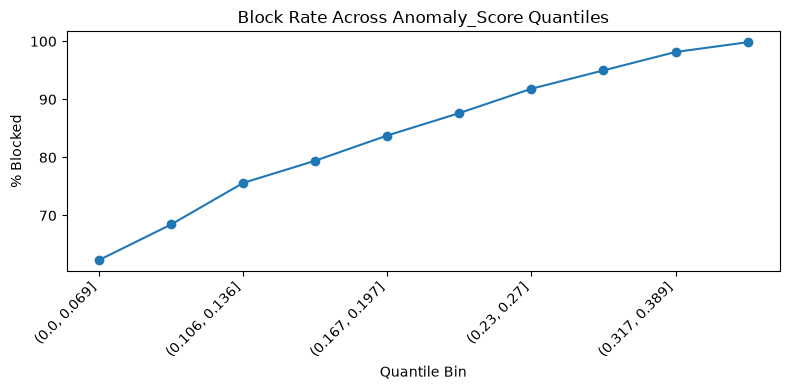


### Policy_Compliance_Score


,Records,Block_Rate,Min_Value,Max_Value,Mean_Value
Bin,,,,,
"(41.739000000000004, 69.239]",5000,100.000,41.740,69.230,64.520
"(69.239, 73.538]",5000,99.600,69.240,73.530,71.549
"(73.538, 76.69]",5004,97.962,73.540,76.690,75.155
"(76.69, 79.44]",5000,95.140,76.700,79.440,78.092
"(79.44, 82.0]",5001,91.762,79.450,82.000,80.729
"(82.0, 84.55]",5000,86.440,82.010,84.550,83.286
"(84.55, 87.27]",5004,81.395,84.560,87.270,85.891
"(87.27, 90.46]",4992,73.858,87.280,90.460,88.827
"(90.46, 94.82]",5005,64.096,90.470,94.820,92.476


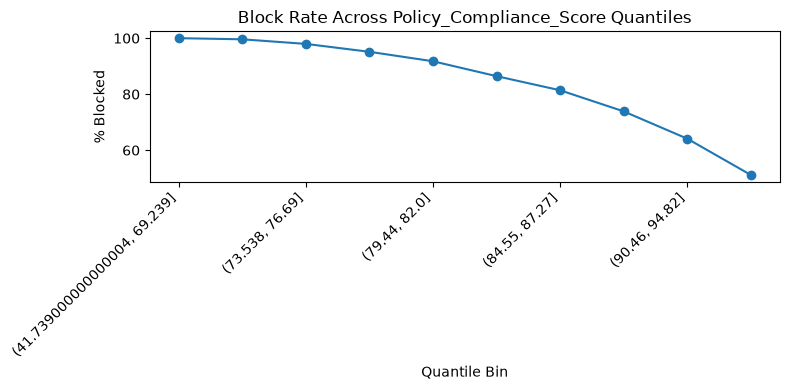


### Governance_Score


,Records,Block_Rate,Min_Value,Max_Value,Mean_Value
Bin,,,,,
"(23.948999999999998, 41.7]",5011,100.000,23.950,41.700,38.359
"(41.7, 45.06]",4994,100.000,41.710,45.060,43.496
"(45.06, 47.57]",5006,100.000,45.070,47.570,46.344
"(47.57, 49.71]",4991,100.000,47.580,49.710,48.670
"(49.71, 51.63]",5010,100.000,49.720,51.630,50.685
"(51.63, 53.44]",5001,100.000,51.640,53.440,52.551
"(53.44, 55.19]",5007,100.000,53.450,55.190,54.322
"(55.19, 57.1]",4988,100.000,55.200,57.100,56.131
"(57.1, 59.51]",5010,41.198,57.110,59.510,58.240


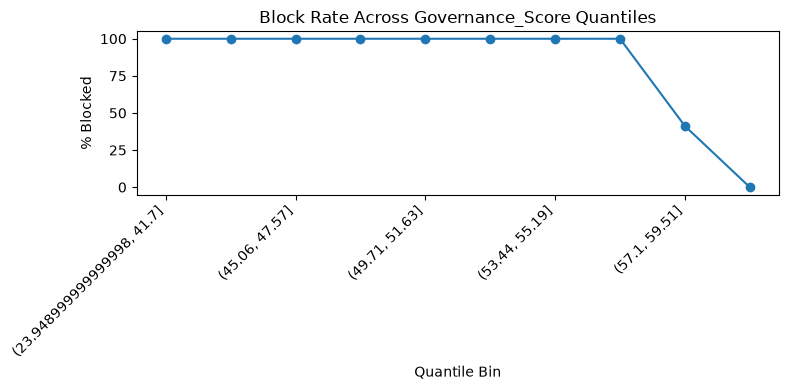

In [8]:
def quantile_block_profile(data, feature, q=10):
    temp = data[[feature, "Is_Blocked"]].dropna().copy()

    temp["Bin"] = pd.qcut(
        temp[feature],
        q=q,
        duplicates="drop"
    )

    profile = (
        temp.groupby("Bin", observed=False)
        .agg(
            Records=("Is_Blocked", "size"),
            Block_Rate=("Is_Blocked", "mean"),
            Min_Value=(feature, "min"),
            Max_Value=(feature, "max"),
            Mean_Value=(feature, "mean")
        )
    )

    profile["Block_Rate"] *= 100

    return profile

threshold_features = [
    "Anomaly_Score",
    "Policy_Compliance_Score",
    "Governance_Score"
]

for col in threshold_features:
    print(f"\n### {col}")
    profile = quantile_block_profile(df_exp, col, q=10)
    display(profile.round(3))

    ax = profile["Block_Rate"].plot(
        kind="line",
        marker="o",
        figsize=(8, 4)
    )
    ax.set_title(f"Block Rate Across {col} Quantiles")
    ax.set_xlabel("Quantile Bin")
    ax.set_ylabel("% Blocked")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


# 9. Permission as a Potential Hard Rule

We explicitly test whether records without permission are always blocked.

If this happens systematically, `Permission_Granted` may behave like a gate in the synthetic decision logic.


In [9]:
permission_rule_check = (
    df_exp.groupby("Permission_Granted")
    .agg(
        Records=("User_ID", "size"),
        Blocked=("Is_Blocked", "sum"),
        Block_Rate=("Is_Blocked", "mean")
    )
)

permission_rule_check["Block_Rate"] *= 100

display(permission_rule_check.round(2))


,Records,Blocked,Block_Rate
Permission_Granted,,,
False,15931,15929,99.990
True,34069,26143,76.740


In [10]:
no_permission = df_exp[
    df_exp["Permission_Granted"] == False
]

non_blocked_without_permission = (
    no_permission["Access_Decision"]
    .ne("Block")
    .sum()
)

print(
    "Records without permission that were not blocked:",
    non_blocked_without_permission
)


Records without permission that were not blocked: 2


# 10. Conditional Analysis — Records with Permission Only

If `Permission_Granted=False` behaves like a hard rule, it can dominate every other analysis.

To understand the **contextual decision logic**, we therefore analyze the subset where permission already exists.


In [11]:
df_permitted = df_exp[
    df_exp["Permission_Granted"] == True
].copy()

print(f"Permitted records: {len(df_permitted):,}")
print(
    f"Block rate among permitted records: "
    f"{df_permitted['Is_Blocked'].mean() * 100:.2f}%"
)


Permitted records: 34,069
Block rate among permitted records: 76.74%


In [12]:
permitted_dimensions = [
    "Role",
    "CRM_Action",
    "Device_Type",
    "Data_Sensitivity",
    "Failed_Logins"
]

for col in permitted_dimensions:
    print(f"\n### {col} — Permission_Granted=True")
    display(block_rate_summary(df_permitted, col))



### Role — Permission_Granted=True


,Records,Block_Rate
Role,,
Support,4210,77.200
Analyst,4072,77.190
Admin,4982,76.760
Sales Rep,11085,76.750
Manager,9720,76.320



### CRM_Action — Permission_Granted=True


,Records,Block_Rate
CRM_Action,,
ExportCRM,1227,77.340
CreateOpportunity,9924,76.770
ViewLead,17696,76.760
ApproveDiscount,1428,76.610
EditLead,3703,76.530
DeleteLead,91,69.230



### Device_Type — Permission_Granted=True


,Records,Block_Rate
Device_Type,,
BYOD,6805,86.380
Managed,27264,74.330



### Data_Sensitivity — Permission_Granted=True


,Records,Block_Rate
Data_Sensitivity,,
5,6900,88.160
4,6831,83.900
3,6794,78.230
2,6829,69.780
1,6715,63.280



### Failed_Logins — Permission_Granted=True


,Records,Block_Rate
Failed_Logins,,
6,1,100.000
5,5,100.000
4,47,100.000
3,434,98.850
2,2653,92.350
1,10360,83.700
0,20569,70.690


# 11. Interaction Analysis

Governance decisions are often contextual.

We therefore examine whether combinations of variables create stronger patterns than isolated variables.


In [13]:
interaction_pairs = [
    ("CRM_Action", "Data_Sensitivity"),
    ("Device_Type", "Data_Sensitivity"),
    ("Role", "CRM_Action"),
    ("Failed_Logins", "Data_Sensitivity")
]

for left, right in interaction_pairs:
    print(f"\n### {left} × {right}")

    pivot = pd.pivot_table(
        df_permitted,
        values="Is_Blocked",
        index=left,
        columns=right,
        aggfunc="mean"
    ).mul(100).round(2)

    display(pivot)



### CRM_Action × Data_Sensitivity


Data_Sensitivity,1,2,3,4,5
CRM_Action,,,,,
ApproveDiscount,60.960,72.010,81.160,81.990,84.510
CreateOpportunity,62.660,70.400,77.520,84.180,88.710
DeleteLead,50.000,56.250,72.730,78.570,94.120
EditLead,63.620,69.230,78.110,83.380,87.530
ExportCRM,66.520,69.470,75.490,86.180,88.800
ViewLead,63.590,69.450,78.620,83.880,88.210



### Device_Type × Data_Sensitivity


Data_Sensitivity,1,2,3,4,5
Device_Type,,,,,
BYOD,76.380,80.590,87.650,92.380,94.710
Managed,60.060,66.990,75.940,81.730,86.550



### Role × CRM_Action


CRM_Action,ApproveDiscount,CreateOpportunity,DeleteLead,EditLead,ExportCRM,ViewLead
Role,,,,,,
Admin,74.850,77.050,69.230,75.160,80.700,77.750
Analyst,NaN,75.140,NaN,NaN,NaN,78.310
Manager,77.540,76.130,NaN,77.230,75.720,75.600
Sales Rep,NaN,77.140,NaN,NaN,NaN,76.540
Support,NaN,78.010,NaN,NaN,NaN,76.730



### Failed_Logins × Data_Sensitivity


Data_Sensitivity,1,2,3,4,5
Failed_Logins,,,,,
0,55.480,62.200,72.530,79.110,83.720
1,71.420,78.200,85.040,89.740,93.840
2,85.550,89.980,93.280,94.370,98.350
3,96.430,100.000,98.110,100.000,100.000
4,100.000,100.000,100.000,100.000,100.000
5,100.000,100.000,100.000,NaN,100.000
6,NaN,NaN,100.000,NaN,NaN


# 12. Diagnostic Decision Tree — Including `Governance_Score`

A shallow decision tree is first fitted with all available analytical variables, including `Governance_Score`.

This model is a **diagnostic test**, not the main explanatory model.

Its purpose is to answer:

> Does an aggregated governance score already contain enough information to nearly reconstruct the final access decision?

If the answer is yes, strong predictive performance should **not** be interpreted as independent evidence that the model discovered the underlying drivers. Instead, it indicates that `Governance_Score` may be acting as a proxy for the synthetic decision logic.

The model remains shallow because interpretability is more important than predictive optimization.


In [14]:
model_features = [
    "Role",
    "Region",
    "Lead_Source",
    "CRM_Action",
    "Device_Type",
    "Daily_Logins",
    "Failed_Logins",
    "Access_Hour",
    "Data_Sensitivity",
    "Policy_Compliance_Score",
    "Anomaly_Score",
    "Permission_Granted",
    "Governance_Score"
]

X = df_exp[model_features]
y = df_exp["Is_Blocked"]

categorical_model_features = [
    "Role",
    "Region",
    "Lead_Source",
    "CRM_Action",
    "Device_Type",
    "Permission_Granted"
]

numeric_model_features = [
    col for col in model_features
    if col not in categorical_model_features
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_model_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_model_features
        )
    ]
)

tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=250,
    random_state=42,
    class_weight="balanced"
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("tree", tree)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

model.fit(X_train, y_train)

print("Decision tree fitted.")


Decision tree fitted.


# 13. Diagnostic Model Performance

Performance is evaluated only to understand how much decision information is already encoded in the included features.

A near-perfect result is a **diagnostic warning**, not a modeling success by itself. In particular, if the tree relies almost entirely on `Governance_Score`, the next analytical step must remove that feature and investigate the underlying drivers.


In [15]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "ROC AUC"
    ],
    "Value": [
        accuracy_score(y_test, y_pred),
        balanced_accuracy_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ]
})

display(metrics.round(4))


,Metric,Value
0,Accuracy,1.000
1,Balanced Accuracy,1.000
2,ROC AUC,1.000


In [16]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Review", "Block"]
    )
)

cm = confusion_matrix(y_test, y_pred)

confusion = pd.DataFrame(
    cm,
    index=["Actual Review", "Actual Block"],
    columns=["Predicted Review", "Predicted Block"]
)

display(confusion)


              precision    recall  f1-score   support

      Review       1.00      1.00      1.00      1982
       Block       1.00      1.00      1.00     10518

    accuracy                           1.00     12500
   macro avg       1.00      1.00      1.00     12500
weighted avg       1.00      1.00      1.00     12500



,Predicted Review,Predicted Block
Actual Review,1982,0
Actual Block,3,10515


# 14. Diagnostic Tree Visualization

Inspect the first split carefully.

If `Governance_Score` appears at the root and dominates the tree, this is evidence that the aggregated score is functioning as a direct proxy for the decision boundary in the synthetic dataset.


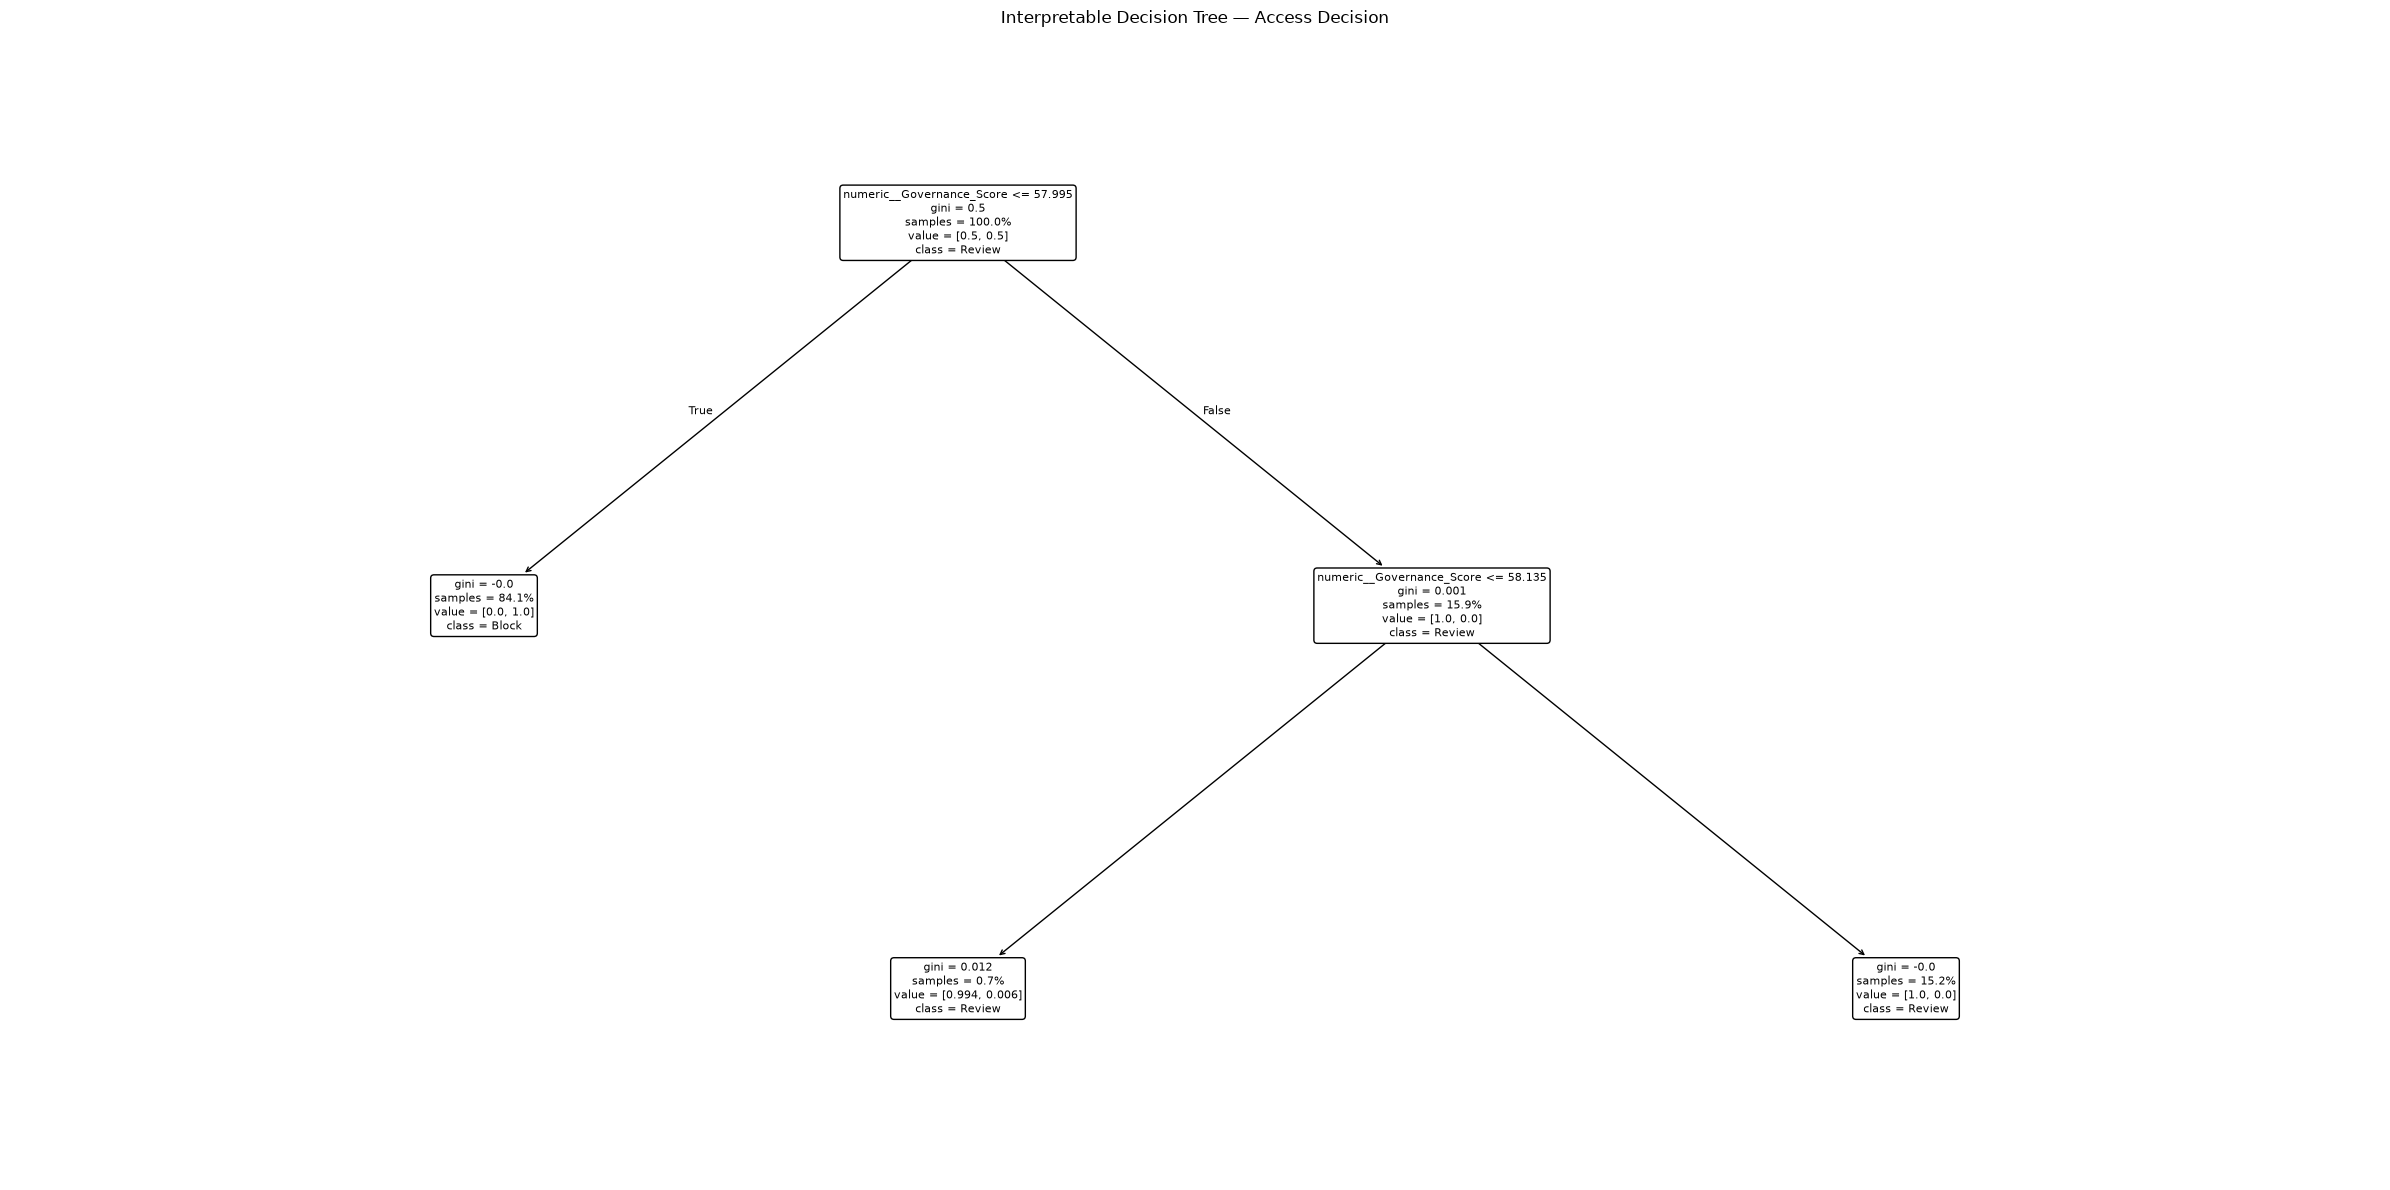

In [17]:
fitted_preprocessor = model.named_steps["preprocessor"]
fitted_tree = model.named_steps["tree"]

feature_names = fitted_preprocessor.get_feature_names_out()

plt.figure(figsize=(24, 12))

plot_tree(
    fitted_tree,
    feature_names=feature_names,
    class_names=["Review", "Block"],
    filled=False,
    rounded=True,
    fontsize=8,
    proportion=True
)

plt.title("Interpretable Decision Tree — Access Decision")
plt.tight_layout()
plt.show()


# 15. Diagnostic Tree Rules

The text representation provides an auditable version of the fitted tree.

The purpose here is to document whether the decision can be reconstructed almost entirely from `Governance_Score`, rather than to convert the learned threshold directly into governance policy.


In [18]:
tree_rules = export_text(
    fitted_tree,
    feature_names=list(feature_names),
    decimals=3
)

print(tree_rules)


|--- numeric__Governance_Score <= 57.995
|   |--- class: 1
|--- numeric__Governance_Score >  57.995
|   |--- numeric__Governance_Score <= 58.135
|   |   |--- class: 0
|   |--- numeric__Governance_Score >  58.135
|   |   |--- class: 0



# 16. Diagnostic Feature Importance

Tree-based importance is used here to diagnose concentration of predictive power.

If one aggregated variable receives nearly all importance, the result suggests that the model is not revealing independent underlying drivers. This is why a second model excluding `Governance_Score` is required.


In [19]:
tree_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": fitted_tree.feature_importances_
})

tree_importance = (
    tree_importance[
        tree_importance["Importance"] > 0
    ]
    .sort_values("Importance", ascending=False)
)

display(tree_importance.head(20).round(4))


,Feature,Importance
30,numeric__Governance_Score,1.000


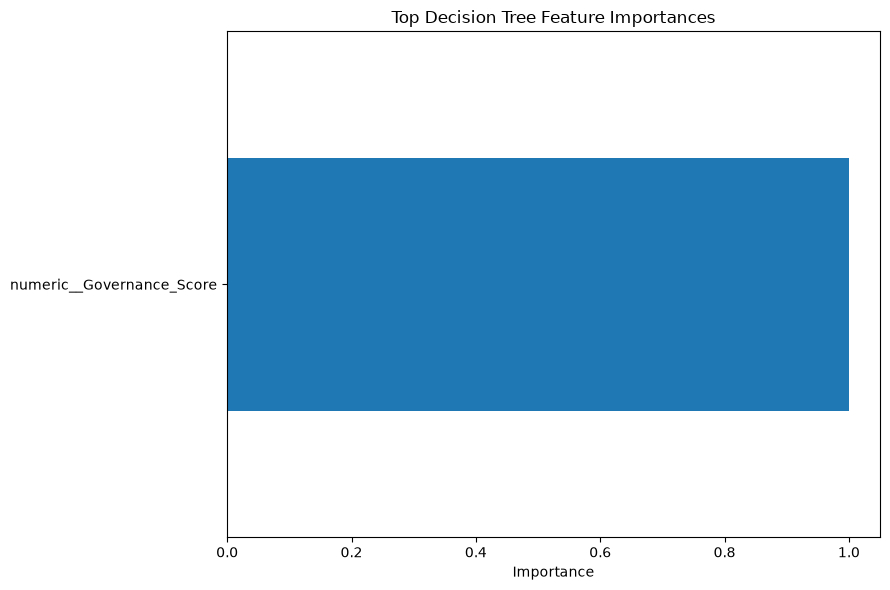

In [20]:
top_tree_importance = (
    tree_importance
    .head(15)
    .sort_values("Importance")
)

ax = top_tree_importance.plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(9, 6),
    legend=False
)

ax.set_title("Top Decision Tree Feature Importances")
ax.set_xlabel("Importance")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


# 17. Diagnostic Permutation Importance

Permutation importance provides the same diagnostic at the original-column level.

If `Governance_Score` dominates while other features contribute almost nothing, the result supports treating the score as a **decision proxy** for explanatory purposes.


In [21]:
perm = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="balanced_accuracy",
    n_jobs=-1
)

permutation_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_Mean": perm.importances_mean,
    "Importance_STD": perm.importances_std
}).sort_values(
    "Importance_Mean",
    ascending=False
)

display(permutation_df.round(4))


,Feature,Importance_Mean,Importance_STD
12,Governance_Score,0.501,0.006
1,Region,0.000,0.000
2,Lead_Source,0.000,0.000
3,CRM_Action,0.000,0.000
0,Role,0.000,0.000
4,Device_Type,0.000,0.000
5,Daily_Logins,0.000,0.000
7,Access_Hour,0.000,0.000
6,Failed_Logins,0.000,0.000
8,Data_Sensitivity,0.000,0.000


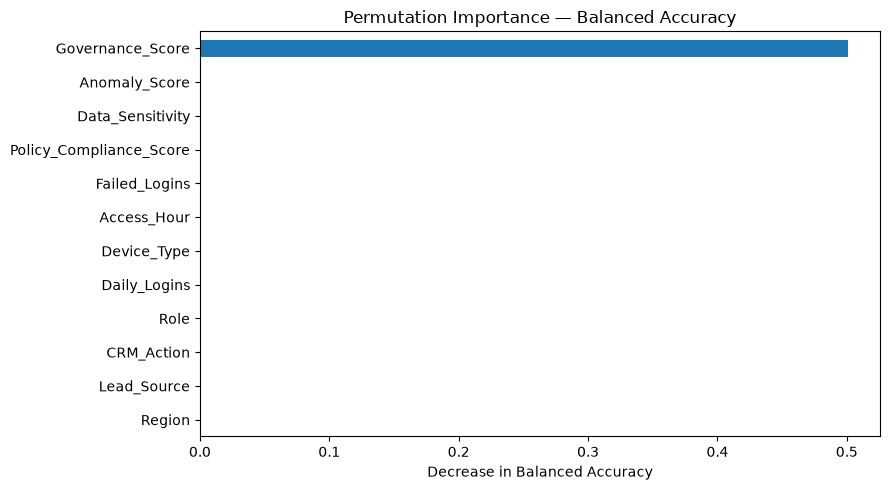

In [22]:
plot_perm = (
    permutation_df
    .head(12)
    .sort_values("Importance_Mean")
)

ax = plot_perm.plot(
    x="Feature",
    y="Importance_Mean",
    kind="barh",
    figsize=(9, 5),
    legend=False
)

ax.set_title("Permutation Importance — Balanced Accuracy")
ax.set_xlabel("Decrease in Balanced Accuracy")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


# 18. Driver Model — Excluding `Governance_Score`

The primary explanatory model removes `Governance_Score`.

This is the key methodological correction in Stage 2.

`Governance_Score` is useful as a governed business metric, but because it almost perfectly separates `Block` and `Review` in the diagnostic model, including it prevents us from learning which **underlying authorization, behavioral, security, and policy variables** carry explanatory information.

This model therefore asks:

> If the aggregate governance score is unavailable, which original variables best reconstruct the access decision?

The output should be interpreted as evidence about the synthetic decision logic — not as production policy.


In [23]:
driver_features = [
    "Role",
    "Region",
    "Lead_Source",
    "CRM_Action",
    "Device_Type",
    "Daily_Logins",
    "Failed_Logins",
    "Access_Hour",
    "Data_Sensitivity",
    "Policy_Compliance_Score",
    "Anomaly_Score",
    "Permission_Granted"
]

X_driver = df_exp[driver_features]
y_driver = df_exp["Is_Blocked"]

driver_categorical = [
    "Role",
    "Region",
    "Lead_Source",
    "CRM_Action",
    "Device_Type",
    "Permission_Granted"
]

driver_numeric = [
    col for col in driver_features
    if col not in driver_categorical
]

driver_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            driver_categorical
        ),
        ("numeric", "passthrough", driver_numeric)
    ]
)

driver_tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=200,
    random_state=42,
    class_weight="balanced"
)

driver_model = Pipeline(
    steps=[
        ("preprocessor", driver_preprocessor),
        ("tree", driver_tree)
    ]
)

Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_driver,
    y_driver,
    test_size=0.25,
    random_state=42,
    stratify=y_driver
)

driver_model.fit(Xd_train, yd_train)

print("Proxy-free driver model fitted.")


Proxy-free driver model fitted.


# 19. Driver Model Performance and Importance

This performance should normally be lower than the diagnostic model because the aggregate score has been removed.

That reduction is **desirable for explanation**: it forces the model to expose the contribution of the underlying variables rather than reuse a composite score.

Focus on:

- balanced accuracy rather than accuracy alone;
- which variables appear in the first tree splits;
- permutation importance at the original-column level;
- whether the results agree with the univariate and interaction analyses.


,Metric,Value
0,Accuracy,0.908
1,Balanced Accuracy,0.924
2,ROC AUC,0.963


|--- numeric__Policy_Compliance_Score <= 82.775
|   |--- numeric__Anomaly_Score <= 0.109
|   |   |--- numeric__Policy_Compliance_Score <= 76.010
|   |   |   |--- numeric__Data_Sensitivity <= 1.500
|   |   |   |   |--- numeric__Policy_Compliance_Score <= 71.575
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- numeric__Policy_Compliance_Score >  71.575
|   |   |   |   |   |--- class: 0
|   |   |   |--- numeric__Data_Sensitivity >  1.500
|   |   |   |   |--- numeric__Anomaly_Score <= 0.043
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- numeric__Anomaly_Score >  0.043
|   |   |   |   |   |--- class: 1
|   |   |--- numeric__Policy_Compliance_Score >  76.010
|   |   |   |--- categorical__Permission_Granted_True <= 0.500
|   |   |   |   |--- class: 1
|   |   |   |--- categorical__Permission_Granted_True >  0.500
|   |   |   |   |--- numeric__Data_Sensitivity <= 3.500
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- numeric__Data_Sensitivity >  3.500
|   |   |   |   |   |--

,Feature,Importance_Mean,Importance_STD
9,Policy_Compliance_Score,0.245,0.003
10,Anomaly_Score,0.179,0.003
11,Permission_Granted,0.176,0.002
8,Data_Sensitivity,0.036,0.003
3,CRM_Action,0.000,0.000
2,Lead_Source,0.000,0.000
1,Region,0.000,0.000
0,Role,0.000,0.000
7,Access_Hour,0.000,0.000
6,Failed_Logins,0.000,0.000


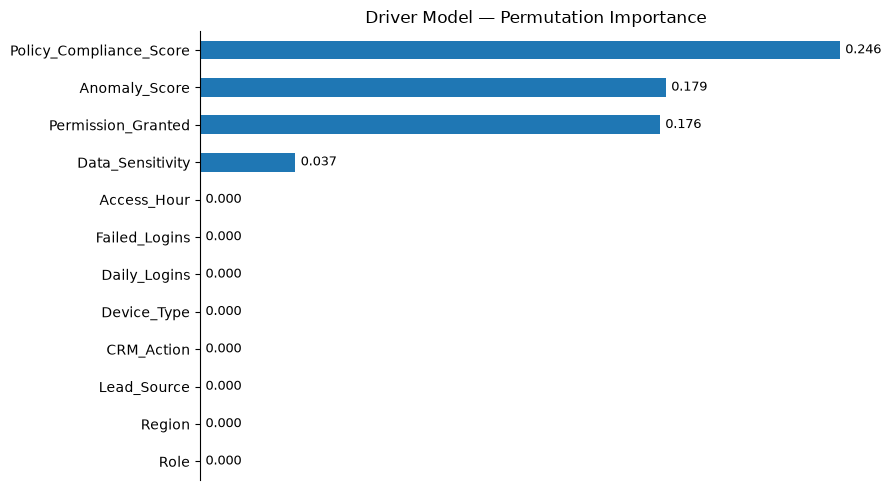

In [24]:
yd_pred = driver_model.predict(Xd_test)
yd_prob = driver_model.predict_proba(Xd_test)[:, 1]

driver_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Balanced Accuracy", "ROC AUC"],
    "Value": [
        accuracy_score(yd_test, yd_pred),
        balanced_accuracy_score(yd_test, yd_pred),
        roc_auc_score(yd_test, yd_prob)
    ]
})

display(driver_metrics.round(4))

# Tree rules
fitted_driver_preprocessor = driver_model.named_steps["preprocessor"]
fitted_driver_tree = driver_model.named_steps["tree"]
driver_feature_names = fitted_driver_preprocessor.get_feature_names_out()

print(export_text(
    fitted_driver_tree,
    feature_names=list(driver_feature_names),
    decimals=3
))

# Permutation importance on original columns
driver_perm = permutation_importance(
    driver_model,
    Xd_test,
    yd_test,
    n_repeats=5,
    random_state=42,
    scoring="balanced_accuracy",
    n_jobs=-1
)

driver_permutation_df = pd.DataFrame({
    "Feature": Xd_test.columns,
    "Importance_Mean": driver_perm.importances_mean,
    "Importance_STD": driver_perm.importances_std
}).sort_values("Importance_Mean", ascending=False)

display(driver_permutation_df.round(4))

plot_driver_perm = (
    driver_permutation_df
    .head(12)
    .sort_values("Importance_Mean")
)

ax = plot_driver_perm.plot(
    x="Feature",
    y="Importance_Mean",
    kind="barh",
    figsize=(9, 5),
    legend=False
)

ax.set_title("Driver Model — Permutation Importance")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=4, fontsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)

plt.tight_layout()
plt.show()


# 20. Contextual Driver Model — Permission Granted Only

The next model answers a different governance question.

The dataset is restricted to `Permission_Granted=True`, and `Governance_Score` is also excluded.

This isolates the **contextual risk layer after authorization already exists**.

The model therefore investigates whether variables such as:

- `Data_Sensitivity`;
- `Failed_Logins`;
- `Device_Type`;
- `Anomaly_Score`;
- `Policy_Compliance_Score`;
- `CRM_Action`;

still help explain why a permitted access is blocked.

This is the model most directly connected to Stage 3 contextual governance rules.


In [25]:
context_features = [
    "Role",
    "Region",
    "Lead_Source",
    "CRM_Action",
    "Device_Type",
    "Daily_Logins",
    "Failed_Logins",
    "Access_Hour",
    "Data_Sensitivity",
    "Policy_Compliance_Score",
    "Anomaly_Score"
]

X_context = df_permitted[context_features]
y_context = df_permitted["Is_Blocked"]

categorical_context = [
    "Role",
    "Region",
    "Lead_Source",
    "CRM_Action",
    "Device_Type"
]

numeric_context = [
    col for col in context_features
    if col not in categorical_context
]

context_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_context
        ),
        ("numeric", "passthrough", numeric_context)
    ]
)

context_tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=150,
    random_state=42,
    class_weight="balanced"
)

context_model = Pipeline(
    steps=[
        ("preprocessor", context_preprocessor),
        ("tree", context_tree)
    ]
)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_context,
    y_context,
    test_size=0.25,
    random_state=42,
    stratify=y_context
)

context_model.fit(Xc_train, yc_train)

yc_pred = context_model.predict(Xc_test)
yc_prob = context_model.predict_proba(Xc_test)[:, 1]

context_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Balanced Accuracy", "ROC AUC"],
    "Value": [
        accuracy_score(yc_test, yc_pred),
        balanced_accuracy_score(yc_test, yc_pred),
        roc_auc_score(yc_test, yc_prob)
    ]
})

display(context_metrics.round(4))


,Metric,Value
0,Accuracy,0.882
1,Balanced Accuracy,0.905
2,ROC AUC,0.963


# 21. Contextual Rules and Importance

The contextual tree should be read as a compact representation of **risk conditions after authorization**.

Do not convert tree splits directly into policy thresholds. Instead, compare them with the earlier descriptive evidence and use them to support transparent rule design in Stage 3.


|--- numeric__Policy_Compliance_Score <= 83.795
|   |--- numeric__Anomaly_Score <= 0.120
|   |   |--- numeric__Policy_Compliance_Score <= 76.125
|   |   |   |--- numeric__Data_Sensitivity <= 1.500
|   |   |   |   |--- numeric__Policy_Compliance_Score <= 71.835
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- numeric__Policy_Compliance_Score >  71.835
|   |   |   |   |   |--- class: 0
|   |   |   |--- numeric__Data_Sensitivity >  1.500
|   |   |   |   |--- numeric__Anomaly_Score <= 0.037
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- numeric__Anomaly_Score >  0.037
|   |   |   |   |   |--- class: 1
|   |   |--- numeric__Policy_Compliance_Score >  76.125
|   |   |   |--- numeric__Data_Sensitivity <= 3.500
|   |   |   |   |--- numeric__Failed_Logins <= 0.500
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- numeric__Failed_Logins >  0.500
|   |   |   |   |   |--- class: 0
|   |   |   |--- numeric__Data_Sensitivity >  3.500
|   |   |   |   |--- numeric__Anomaly_Score <= 

,Feature,Importance_Mean,Importance_STD
9,Policy_Compliance_Score,0.261,0.002
10,Anomaly_Score,0.219,0.004
8,Data_Sensitivity,0.046,0.004
6,Failed_Logins,0.007,0.001
2,Lead_Source,0.000,0.000
0,Role,0.000,0.000
1,Region,0.000,0.000
5,Daily_Logins,0.000,0.000
4,Device_Type,0.000,0.000
3,CRM_Action,0.000,0.000


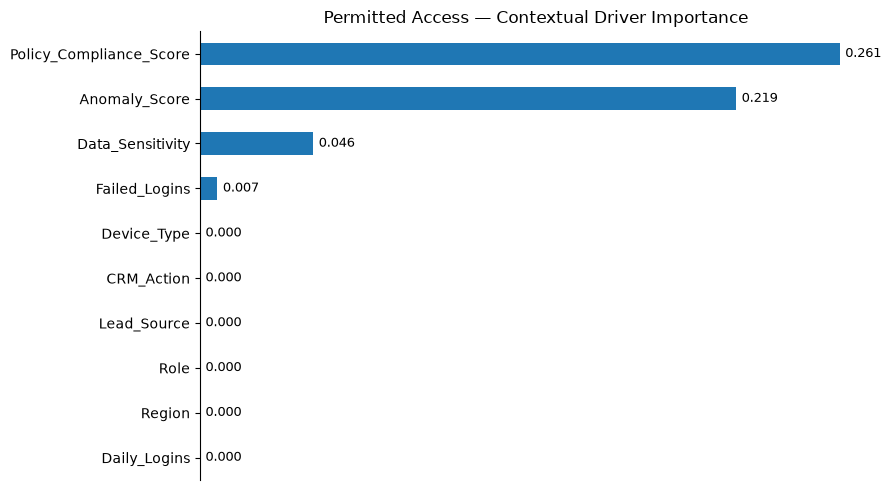

In [26]:
context_preprocessor_fitted = context_model.named_steps["preprocessor"]
context_tree_fitted = context_model.named_steps["tree"]
context_feature_names = context_preprocessor_fitted.get_feature_names_out()

context_rules = export_text(
    context_tree_fitted,
    feature_names=list(context_feature_names),
    decimals=3
)

print(context_rules)

context_perm = permutation_importance(
    context_model,
    Xc_test,
    yc_test,
    n_repeats=5,
    random_state=42,
    scoring="balanced_accuracy",
    n_jobs=-1
)

context_permutation_df = pd.DataFrame({
    "Feature": Xc_test.columns,
    "Importance_Mean": context_perm.importances_mean,
    "Importance_STD": context_perm.importances_std
}).sort_values("Importance_Mean", ascending=False)

display(context_permutation_df.round(4))

plot_context_perm = (
    context_permutation_df
    .head(10)
    .sort_values("Importance_Mean")
)

ax = plot_context_perm.plot(
    x="Feature",
    y="Importance_Mean",
    kind="barh",
    figsize=(9, 5),
    legend=False
)

ax.set_title("Permitted Access — Contextual Driver Importance")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=4, fontsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)

plt.tight_layout()
plt.show()


# 22. Explanatory Evidence Summary

This section consolidates evidence into a form that can be traced into Stage 3 governance rules.

## 22.1 Target and authorization evidence

- `Block` represents **84.14%** of the dataset; `Review` represents **15.86%**.
- `Permission_Granted` has the strongest categorical association with the target (`Cramér's V ≈ 0.296`).
- Records with `Permission_Granted=False` are blocked in **99.99%** of cases.
- Permission does **not** guarantee access: permitted records still show a **76.74%** block rate.

**Interpretation:** authorization behaves close to a gate when permission is absent, but contextual controls still matter when permission exists.

## 22.2 Strongest categorical evidence

Approximate Cramér's V values from the executed analysis:

- `Permission_Granted`: **0.296**
- `CRM_Action`: **0.225**
- `Data_Sensitivity`: **0.168**
- `Failed_Logins`: **0.147**
- `Role`: **0.131**
- `Device_Type`: **0.089**
- `Region` and `Lead_Source`: approximately **0.000**

**Interpretation:** authorization, action context, sensitivity, and failed authentication attempts carry substantially more explanatory signal than geography or lead source.

## 22.3 Strongest numerical evidence

Standardized mean differences:

- `Governance_Score`: **|SMD| ≈ 2.10**
- `Policy_Compliance_Score`: **|SMD| ≈ 1.20**
- `Anomaly_Score`: **|SMD| ≈ 0.89**
- `Access_Hour`: approximately **0.01**
- `Daily_Logins`: approximately **0.01**

**Interpretation:** the three governance/security scores strongly separate `Block` and `Review`, while simple login frequency and clock hour show little linear separation by themselves.

## 22.4 Threshold patterns

- Higher `Anomaly_Score` quantiles show progressively higher block rates, reaching **99.84%** in the highest decile.
- Higher `Policy_Compliance_Score` is associated with lower block rates, falling to approximately **51.14%** in the highest compliance decile.
- `Governance_Score` exhibits an exceptionally sharp transition around **58**, which explains the perfect or near-perfect performance of the diagnostic tree.

**Interpretation:** `Governance_Score` should be treated as an aggregated decision proxy during explanatory modeling, not as independent proof of the underlying drivers.

## 22.5 Context after permission exists

Within `Permission_Granted=True`:

- BYOD: **86.38%** blocked vs. Managed: **74.33%**.
- Data sensitivity increases monotonically from **63.28%** blocked at level 1 to **88.16%** at level 5.
- Failed logins increase from **70.69%** blocked at zero failures to **98.85%** at three failures; sparse higher-failure groups reach 100%.
- Role and CRM action differences become much smaller after conditioning on permission.

**Interpretation:** once authorization exists, device context, data sensitivity, and failed authentication attempts remain important risk signals.

## 22.6 Interaction evidence

The permitted-access interaction tables indicate that risk compounds when factors occur together. Examples include:

1. BYOD combined with higher data sensitivity.
2. Failed logins combined with higher data sensitivity.
3. Sensitive actions combined with higher sensitivity levels.

These are candidate inputs for Stage 3 contextual rules, not final policy thresholds.

## 22.7 Model diagnostics

### Diagnostic model including `Governance_Score`
- Observed balanced accuracy: approximately **1.00**.
- The tree relies almost entirely on `Governance_Score` around a threshold near **58**.

**Interpretation:** this is evidence of a proxy-like relationship between the aggregate score and the target. It is not sufficient as independent explanatory evidence.

### Driver model excluding `Governance_Score`
- Record balanced accuracy after execution:
- Record top original-variable permutation importances:
- Compare results with Cramér's V, SMD, and interaction evidence.

### Permitted-access contextual model excluding `Governance_Score`
- Record balanced accuracy after execution:
- Record top contextual variables after execution:
- Confirm whether device, sensitivity, failed logins, anomaly, compliance, and action remain important after authorization.


# 23. Governance Interpretation Framework

The explanatory evidence should be converted into governance through three clearly separated layers.

### Layer 1 — Authorization

Questions such as:

- Does the user's role permit the requested CRM action?
- Does the user have explicit permission?

This is aligned with **Role-Based Access Control (RBAC)** and authorization governance.

### Layer 2 — Contextual Risk

Even when authorization exists, contextual conditions may increase risk:

- sensitive data;
- unmanaged/BYOD devices;
- anomalous behavior;
- failed login attempts;
- policy-compliance conditions;
- sensitive CRM actions.

This resembles **risk-based / context-aware access control**.

### Layer 3 — Decision and Exception Handling

The governance decision should combine authorization and contextual risk through transparent rules such as:

`Allow / Review / Block`

The current synthetic dataset contains only `Review` and `Block`. Stage 3 must therefore distinguish between **observed dataset behavior** and any **proposed future `Allow` policy state**.

### Evidence-to-control principle

A statistical association is not automatically a governance rule.

For every proposed Stage 3 rule, document:

1. analytical evidence;
2. business rationale;
3. risk addressed;
4. proposed control;
5. exception/review path;
6. ownership and future monitoring requirement.


# 24. Limitations and Analytical Boundaries

1. The dataset is synthetic.
2. Statistical association does not imply causation.
3. Feature importance does not automatically define policy importance.
4. Decision-tree thresholds are learned from this dataset and must not be treated as universal security thresholds.
5. `Access_Decision` contains only `Block` and `Review`.
6. There is no real customer-level PII in this dataset.
7. `Governance_Score` appears to encode a large portion of the decision boundary; this creates a proxy/leakage-like risk for explanatory modeling.
8. The proxy-free driver models reduce this risk but still describe synthetic relationships rather than real organizational behavior.
9. Business, security, privacy, legal, and data-owner validation would be required before implementing any governance rule in a real CRM environment.
10. Stage 3 must preserve a clear distinction between **observed evidence**, **proposed policy**, and **implemented control**.


# 25. Stage 2 Deliverables

This notebook should produce the following reusable project artifacts:

- ranked categorical association table;
- standardized numerical effect-size table;
- score threshold profiles;
- permission-gate evidence;
- permitted-access conditional profiles;
- interaction tables;
- diagnostic proxy analysis for `Governance_Score`;
- proxy-free driver model;
- proxy-free permitted-access contextual model;
- explanatory evidence summary;
- documented analytical limitations.

These artifacts provide traceable inputs for later governance, quality, metadata, privacy, lineage, monitoring, and AI-governance stages.


# 26. Next Step — Stage 3: Governance Rules

The evidence generated here will support **Stage 3 of 12 — Governance Rules**.

Planned outputs:

- `Role × CRM_Action` access-control matrix;
- proposed data-sensitivity governance levels;
- authorization rules;
- contextual risk rules;
- exception and human-review logic;
- rule priority and evaluation order;
- documentation of rule rationale;
- mapping from each proposed control back to Stage 2 analytical evidence.

### Handoff requirement

Stage 3 must not simply copy statistical thresholds into policy.

It should transform evidence into a **transparent, documented, auditable, and reviewable governance framework**, clearly labeling each item as:

- observed evidence;
- proposed governance rule;
- exception logic;
- monitoring requirement.

After Stage 3, the project continues into the already completed/defined governance engineering stages and then the remaining roadmap through lineage, operating model, analytical modeling, monitoring, AI governance, and final packaging.
